In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (120271188600)>


In [5]:
# step_rectangle_trapezoid_fragment_fixed.py
import gmsh

# --- Initialize Gmsh ---
gmsh.initialize()
gmsh.model.add("rectangle_trapezoid_fragment")
occ = gmsh.model.occ

# --- Geometry ---
rect1 = occ.addRectangle(0, 0, 0, 40, 5)
rect2 = occ.addRectangle(40, 0, 0, 20, 5)

p1 = occ.addPoint(0, 5, 0)
p2 = occ.addPoint(40, 5, 0)
p3 = occ.addPoint(20, 15, 0)
p4 = occ.addPoint(0, 15, 0)

l1 = occ.addLine(p1, p2)
l2 = occ.addLine(p2, p3)
l3 = occ.addLine(p3, p4)
l4 = occ.addLine(p4, p1)

trap_loop = occ.addCurveLoop([l1, l2, l3, l4])
trap_surf = occ.addPlaneSurface([trap_loop])

occ.synchronize()

# --- Fragment all together ---
occ.fragment([(2, rect1), (2, rect2)], [(2, trap_surf)])
occ.removeAllDuplicates()
occ.synchronize()

# --- Get surface tags ---
surfs = [tag for dim, tag in gmsh.model.getEntities(2)]

# --- Transfinite mesh: surface 1 ---
bound1 = gmsh.model.getBoundary([(2, surfs[0])], oriented=False)
curves1 = [b[1] for b in bound1]
gmsh.model.mesh.setTransfiniteCurve(curves1[0], 20)
gmsh.model.mesh.setTransfiniteCurve(curves1[1], 10)
gmsh.model.mesh.setTransfiniteCurve(curves1[2], 20)
gmsh.model.mesh.setTransfiniteCurve(curves1[3], 10)
gmsh.model.mesh.setTransfiniteSurface(surfs[0])
gmsh.model.mesh.setRecombine(2, surfs[0])

# --- Transfinite mesh: surface 2 ---
bound2 = gmsh.model.getBoundary([(2, surfs[1])], oriented=False)
curves2 = [b[1] for b in bound2]
gmsh.model.mesh.setTransfiniteCurve(curves2[0], 10)
gmsh.model.mesh.setTransfiniteCurve(curves2[1], 20)
gmsh.model.mesh.setTransfiniteCurve(curves2[2], 10)
gmsh.model.mesh.setTransfiniteCurve(curves2[3], 20)
gmsh.model.mesh.setTransfiniteSurface(surfs[1])
gmsh.model.mesh.setRecombine(2, surfs[1])

# --- Transfinite mesh: surface 3 ---
bound3 = gmsh.model.getBoundary([(2, surfs[2])], oriented=False)
curves3 = [b[1] for b in bound3]
gmsh.model.mesh.setTransfiniteCurve(curves3[0], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[1], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[2], 20)
gmsh.model.mesh.setTransfiniteCurve(curves3[3], 20)
gmsh.model.mesh.setTransfiniteSurface(surfs[2])
gmsh.model.mesh.setRecombine(2, surfs[2])

#p5 = occ.addPoint(4.21, 15.249, 0)
#p6 = occ.addPoint(15.78, 15.249, 0)
#l5 = occ.addLine(p5, p6)
#gmsh.model.occ.synchronize()
#gmsh.model.mesh.setTransfiniteCurve(11, 12)

# --- Physical lines ---
# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support_a")

gmsh.model.addPhysicalGroup(1, [5], tag=202)
gmsh.model.setPhysicalName(1, 202, "bottom_support_b")

gmsh.model.addPhysicalGroup(1, [4], tag=203)
gmsh.model.setPhysicalName(1, 203, "left_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=204)
gmsh.model.setPhysicalName(1, 204, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [10], tag=205)
gmsh.model.setPhysicalName(1, 205, "left_top_support")

gmsh.model.addPhysicalGroup(1, [9], tag=206)
gmsh.model.setPhysicalName(1, 206, "loadings")

gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot_a")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_bot_b")

gmsh.model.addPhysicalGroup(2, [3], 303)
gmsh.model.setPhysicalName(2, 303, "soil_top")

gmsh.model.addPhysicalGroup(1, [11], tag=304)
gmsh.model.setPhysicalName(1, 304, "beam")

# Get coordinates for a specific node ID
#node_tag = 137  # replace with your actual node tag
#node_coords = gmsh.model.mesh.getNode(node_tag)[0]  # returns (x, y, z)
#print(f"Node {node_tag} coordinates: {node_coords}")

# --- Finalize mesh ---
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("slope_stability_fixed.msh")
#gmsh.fltk.run()
#gmsh.finalize()


In [6]:
GMSH2OPS = opst.pre.Gmsh2OPS(ndm=2, ndf=2)
GMSH2OPS.read_gmsh_file("slope_stability_fixed.msh")
gmsh.finalize()

Info:: 10 Physical Names.
Info:: 770 Nodes; MaxNodeTag 770; MinNodeTag 1.
Info:: 797 Elements; MaxEleTag 797; MinEleTag 1.
Info:: Geometry Information >>>
21 Entities: 8 Point; 10 Curves; 3 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
9 Physical Groups.
Physical Group names: ['bottom_support_a', 'left_bot_support', 'bottom_support_b', 'right_bot_support', 'loadings', 'left_top_support', 'soil_bot_a', 'soil_bot_b', 'soil_top']

Info:: Mesh Information >>>
770 Nodes; MaxNodeTag 770; MinNodeTag 1.
797 Elements; MaxEleTag 797; MinEleTag 1.



In [7]:
GMSH2OPS.get_physical_groups()

{'bottom_support_a': [(1, 1)],
 'left_bot_support': [(1, 4)],
 'bottom_support_b': [(1, 5)],
 'right_bot_support': [(1, 6)],
 'loadings': [(1, 9)],
 'left_top_support': [(1, 10)],
 'soil_bot_a': [(2, 1)],
 'soil_bot_b': [(2, 2)],
 'soil_top': [(2, 3)]}

In [8]:
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 2)

In [9]:
# acceleration due to gravity [m/s2]
accg = 9.81
# acceleration due to gravity in the x and y direction
wgt_x = 0.0
wgt_y = -accg

# material properties
# Young's modulus (kPa)
modE = 1e5
# Poisson's ratio of the soil
nu = 0.3
# soil shear modulus from Young's modulus [kPa]
modG = modE / (2 * (1 + nu))
# soil bulk modulus [kPa]
modK = modE / (3 * (1 - 2 * nu))
# soil saturated density, or soil mass density  [Mg/m3] equivalent [1 Mg/m3 = 10 kN/m3]
soil_density = 2.0
# soil friction angle, phi of Mohr-Coulomb failure envelop [deg]
fos = 1.35
friction_angle = 20.0 / fos
# the undrained shear strength, c of Mohr-Coulomb failure envelop [kPa]
cohesion = 10.0 / fos
# related to dilation? controls evolution of plastic volume change, 0 ≤ $rhoBar ≤ $rho
rhobar = 0.0
# nonlinear isotropic strain hardening parameter, $Kinf ≥ 0
kinf = 0.0
# nonlinear isotropic strain hardening parameter, $Ko ≥ 0
ko = 0.0
# nonlinear isotropic strain hardening parameter, $delta1 ≥ 0
delta1 = 0.0
# tension softening parameter, $delta2 ≥ 0
delta2 = 0.0
# linear strain hardening parameter, $H ≥ 0
hard = 0.0
# controls relative proportions of isotropic and kinematic hardening, 0 ≤ $theta ≤ 1
theta = 0.0
# print(f"Soil elastic properites:")
# print(f"G: {modG/1000:6.1f} MPa, E: {modE/1000:6.1f} MPa, K: {modK/1000:6.1f} MPa")


sigma_y_result, rho_result = SF.mc2dp(cohesion, friction_angle)

sigmay = sigma_y_result # Equivalent cohesion
rho = rho_result # Equivalent friction angle
# material type and tag for soil
soil_mattype = "DruckerPrager"
soil_mattag = 5

In [10]:
print(sigmay, rho)

9.039451052815586 0.1521512749127298


In [11]:
ops.nDMaterial(
        soil_mattype,
        soil_mattag,
        modK,
        modG,
        sigmay,
        rho,
        rhobar,
        kinf,
        ko,
        delta1,
        delta2,
        hard,
        theta,
        soil_density,
    )

soil_Fill_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_Fill_mat_tag, soil_mattag, 2)

contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

DruckerPrager nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington
InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [12]:
GMSH2OPS.create_node_cmds()
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"
rho_d = 0.0

soil_groups = [
    "soil_bot_a",
    "soil_bot_b",
    "soil_top"
]

element_args = [soil_Fill_mat_tag, etype, soil_thickness,rho_d, wgt_x, wgt_y] # press, rho_d, unitWeightX, unitWeightY

# Create elements for each soil group
for group_name in soil_groups:
    ele_tags = GMSH2OPS.create_element_cmds(
        ops_ele_type="SSPquad",
        ops_ele_args=element_args,
        physical_group_names=[group_name]
    )

SSPquad element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [13]:
node_id = 137
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")
node_id = 126
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")

Node 137 coordinate: [4.210526315789473, 15.0]
Node 126 coordinate: [15.78947368421053, 15.0]


In [14]:
ops.model("basic", "-ndm", 2, "-ndf", 3)

start_N_id = SF.get_next_node_id(start_from=None)

In [15]:
pad_foundation_coor = [
[20.0000 , 15.0],
[18.9482 , 15.0],
[17.8964 , 15.0],
[16.8445 , 15.0],
[15.7927 , 15.0],
[14.7409 , 15.0],
[13.6891 , 15.0],
[12.6373 , 15.0],
[11.5855 , 15.0],
[10.5336 , 15.0],
[ 9.4818 , 15.0],
[ 8.4300 , 15.0],
]

pad_noodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation_coor, start_id = start_N_id, block_name = "pad_nodes")

In [16]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.3)
print(Iz)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAMs = SF.create_disp_beam_column_chain(beam_nodes = pad_noodes, beam_start_id = 1001,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

0.00225


In [17]:
print(BEAMs)
lining_slave_nodes = [7,123,124,124,125,126,127,128,129,130,131,132]

[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011]


In [18]:
pad_soil = SF.apply_equal_dof_pairs(r_nodes = pad_noodes, c_nodes = lining_slave_nodes , dofs=[1, 2], block_name="equal_dof_pairs")

In [19]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [20]:
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

In [21]:
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_a"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_b"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_bot_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_top_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["right_bot_support"], dofs=fixXonly)
ops.fix(4, *fixXonly)
ops.fix(8, *fixXonly)
ops.fix(6, *fixXonly)
ops.fix(1, *fixXY)
ops.fix(2, *fixXY)
ops.fix(5, *fixXY)

In [22]:
loading_nodes = GMSH2OPS.get_node_tags(physical_group_names="loadings")
print(loading_nodes)

[123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140]


In [23]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [24]:
import openseespy.opensees as ops
import opstool as opst
import opstool.vis.plotly as opsvis

In [25]:
# Newmark parameters
newmark_gamma = 0.5
newmark_beta = 0.25

print(f"Gravity analysis:")
ops.InitialStateAnalysis("on")
# update material stage to 0 for elastic behavior
ops.updateMaterialStage("-material", soil_Fill_mat_tag, "-stage", 0)
#ops.setParameter("-val", 0, "-eleRange", 3050, 3060, "friction")
print(f"Material updated for elastic behavior during gravity loading")
ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1e-5, 30, 5)
ops.algorithm("Newton")
ops.integrator("Newmark", newmark_gamma, newmark_beta)
ops.analysis("Transient")
ops.analyze(10, 500.0)
print(f"Elastic gravity analysis over")
ops.updateMaterialStage("-material", soil_Fill_mat_tag, "-stage", 1)
ops.analyze(40, 500.0)
ops.InitialStateAnalysis("off")
#ops.setParameter("-val", 0, "-eleRange", 3050, 3060, "friction")
print(f"Plastic gravity analysis over")

Gravity analysis:
Material updated for elastic behavior during gravity loading
Elastic gravity analysis over
Plastic gravity analysis over


InitialStateAnalysis ON
InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [26]:
ops.wipeAnalysis()
ops.setTime(0.0)

ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
for bb in BEAMs:
    opst.pre.transform_beam_uniform_load(bb, wy=-27)

opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = True)

In [27]:
ops.recorder('Element', '-ele', 455, '-time', '-file', 'slopesurchargestress1.out', '-dT', 0.1, 'stress')
ops.recorder('Element', '-ele', 455, '-time', '-file', 'slopesurchargestrain1.out', '-dT', 0.1, 'strain')


1

In [28]:
# create constraint handler
alpha = 1e18;
ops.constraints('Penalty',alpha,alpha)
# create DOF number
ops.numberer('RCM')
# create SOE
ops.system('UmfPack')
# create integrator
gamma = 0.6;
beta  = 0.3;
ops.integrator('Newmark',gamma,beta) #CHECK TO MATCH ANALYSIS TYPE 

ODB = opst.post.CreateODB(odb_tag="slopeanalysis") 
analysis = opst.anlys.SmartAnalyze(
    analysis= "Transient",
    testType= "NormDispIncr",
    testTol= 1.0e-10,
    testIterTimes= 25,
    testPrintFlag= 0,
    tryAddTestTimes= True,
    normTol= 1000,
    testIterTimesMore= [50],
    tryLooseTestTol= True,
    looseTestTolTo= 1e-3,
    tryAlterAlgoTypes= True,
    algoTypes= [10, 20, 30, 40, 50, 60, 70, 90],
    UserAlgoArgs= None,
    initialStep= None,
    relaxation= 0.5,
    minStep= 1.0e-6,
    debugMode= False,
    printPer= 20,
)
npts, dt = 30, 0.01
segs = analysis.transient_split(npts)
for seg in segs:
    analysis.TransientAnalyze(dt)
    ODB.fetch_response_step()

ODB.save_response(zlib=True)

Output()

🎉 SmartAnalyze: Successfully finished! Time consumption: 8.361 s. 🎉

OPSTOOL ::  All responses data with _odb_tag = slopeanalysis saved in 
.opstool.output/RespStepData-slopeanalysis.nc!

In [29]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [30]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-slopeanalysis.nc ...

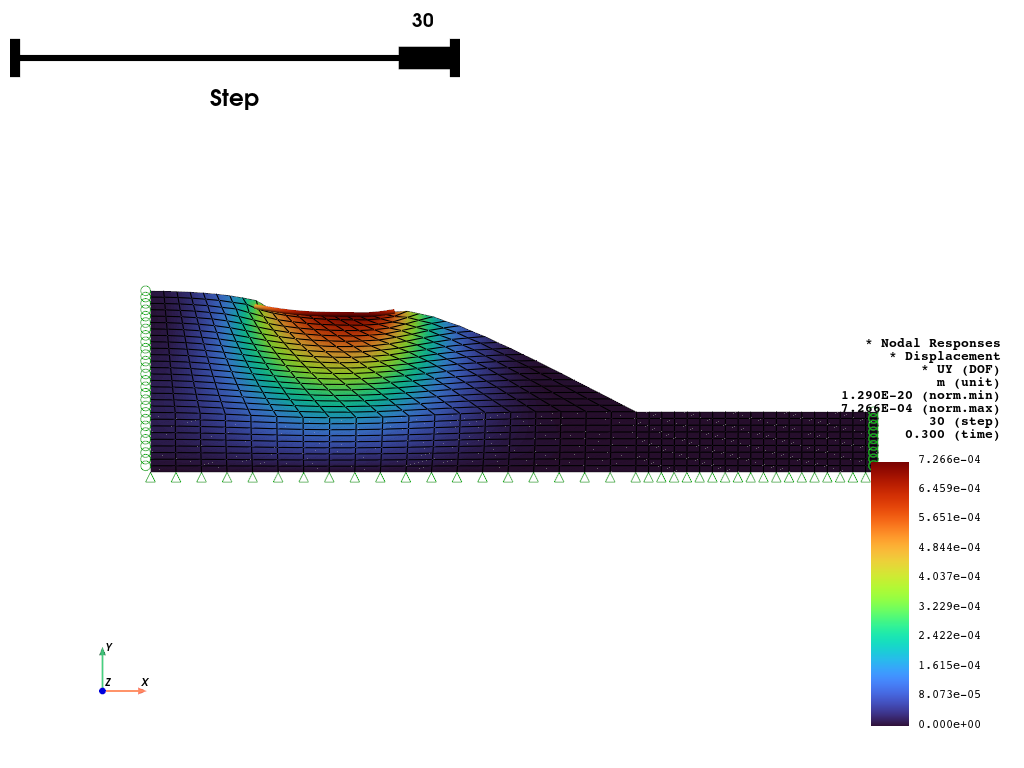

In [31]:
opsvis.plot_nodal_responses(
    odb_tag="slopeanalysis",
    slides=True,
    scale=0.5,
    resp_type="disp",
    resp_dof=["UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-slopeanalysis.nc ...

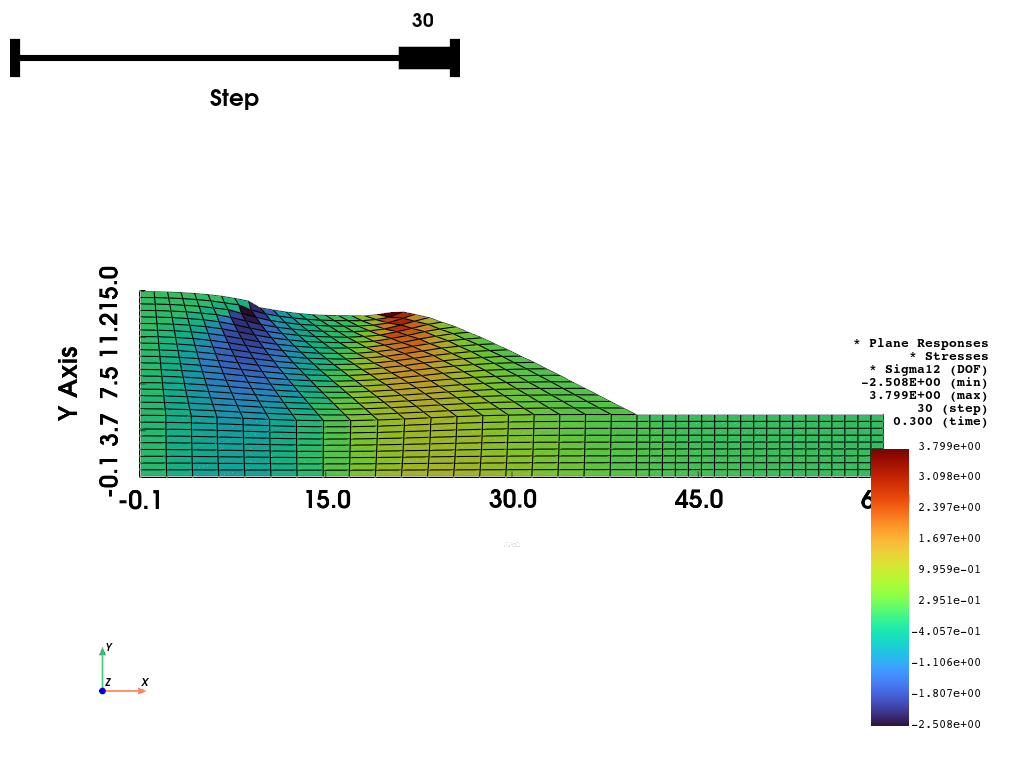

In [32]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="slopeanalysis", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab") 

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-slopeanalysis.nc ...

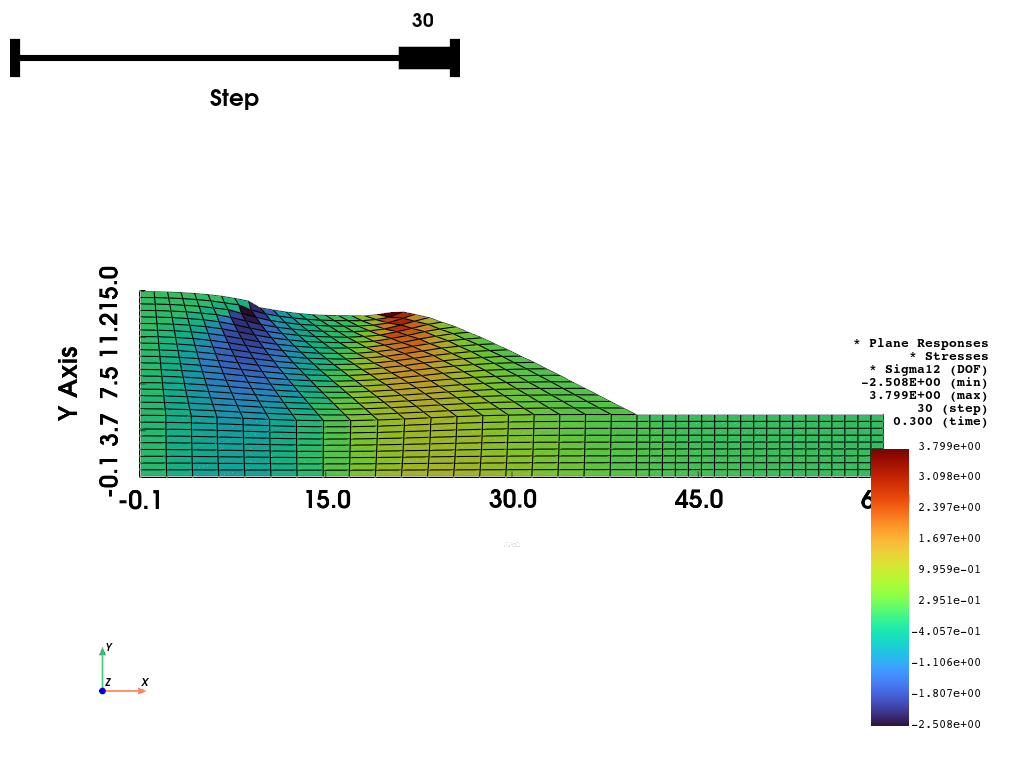

In [33]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="slopeanalysis", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab")

In [34]:
node_resp = opst.post.get_nodal_responses(odb_tag="slopeanalysis")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-slopeanalysis.nc ...

<xarray.Dataset> Size: 4MB
Dimensions:             (time: 31, nodeTags: 782, DOFs: 6)
Coordinates:
  * time                (time) float32 124B 0.0 0.01 0.02 0.03 ... 0.28 0.29 0.3
  * nodeTags            (nodeTags) int64 6kB 1 2 3 4 5 6 ... 778 779 780 781 782
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 582kB 0.0 ... -6.686e-05
    vel                 (time, nodeTags, DOFs) float32 582kB 0.0 ... -0.0003288
    accel               (time, nodeTags, DOFs) float32 582kB 0.0 ... -0.0006271
    reaction            (time, nodeTags, DOFs) float32 582kB 0.0 ... -1.301e-13
    reactionIncInertia  (time, nodeTags, DOFs) float32 582kB 0.0 ... -1.301e-13
    rayleighForces      (time, nodeTags, DOFs) float32 582kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 97kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction

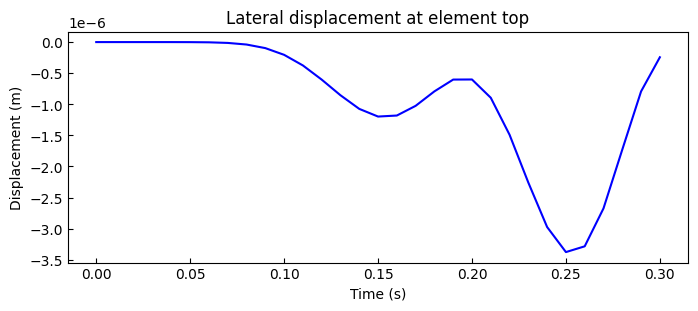

In [35]:
disp1 = node_resp["disp"].sel(nodeTags=105, DOFs="UY")
disp3 = node_resp["disp"].sel(nodeTags=106, DOFs="UY")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

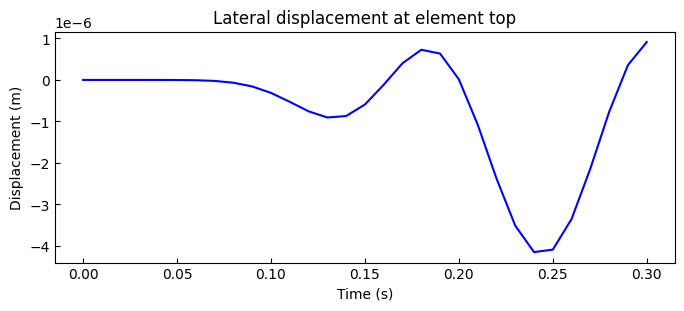

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

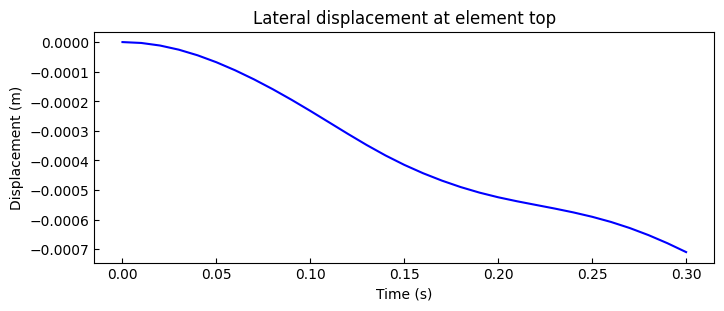

In [37]:
disp3 = node_resp["disp"].sel(nodeTags=777, DOFs="UY")
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [38]:
import openseespy.opensees as ops

import opstool as opst

OPSVIS = opst.vis.pyvista

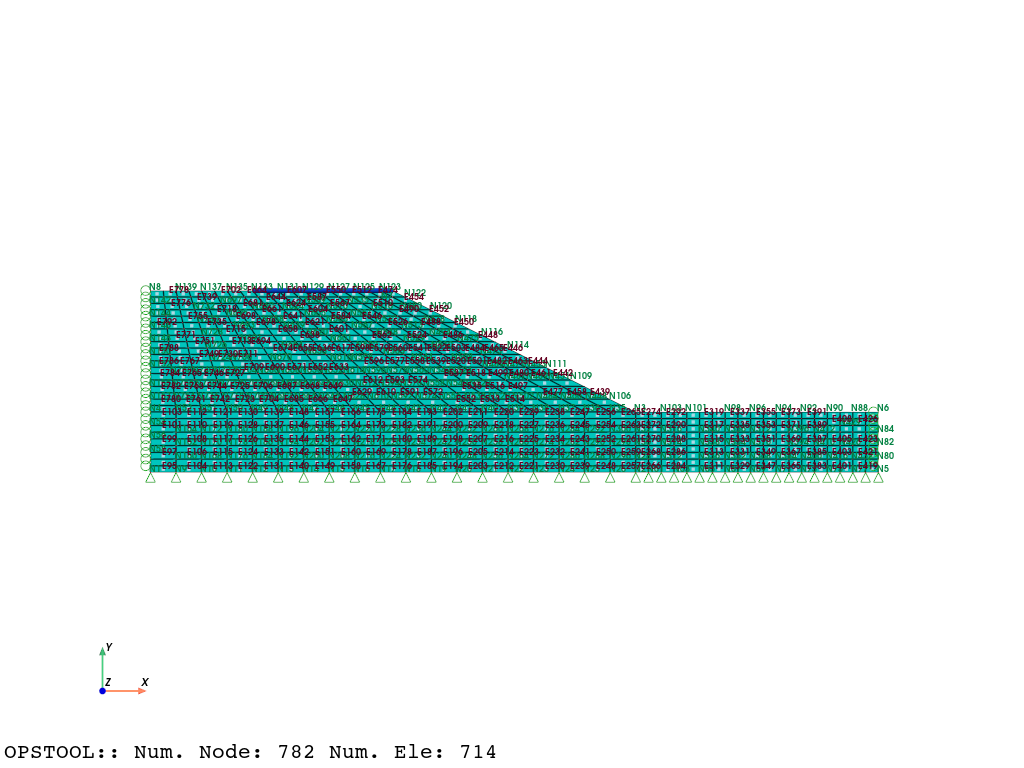

In [39]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [40]:
ele_resp = opst.post.get_element_responses(odb_tag="slopeanalysis", ele_type="Plane")

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-slopeanalysis.nc ...

In [41]:
# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=455).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=455).values
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=455).values
print(sigma11)

[[ 0.        ]
 [-0.07761138]
 [-0.1925565 ]
 [-0.28130972]
 [-0.40254068]
 [-0.5565604 ]
 [-0.73130107]
 [-0.91047984]
 [-1.1023936 ]
 [-1.3101859 ]
 [-1.5273651 ]
 [-1.7483466 ]
 [-1.9630139 ]
 [-2.1687334 ]
 [-2.3567646 ]
 [-2.5215032 ]
 [-2.659337  ]
 [-2.775282  ]
 [-2.8799214 ]
 [-2.983398  ]
 [-3.0920658 ]
 [-3.206591  ]
 [-3.3241034 ]
 [-3.4400318 ]
 [-3.5540934 ]
 [-3.6729426 ]
 [-3.8076422 ]
 [-3.9652112 ]
 [-4.144494  ]
 [-4.338411  ]
 [-4.538132  ]]


In [42]:
eletag = 455

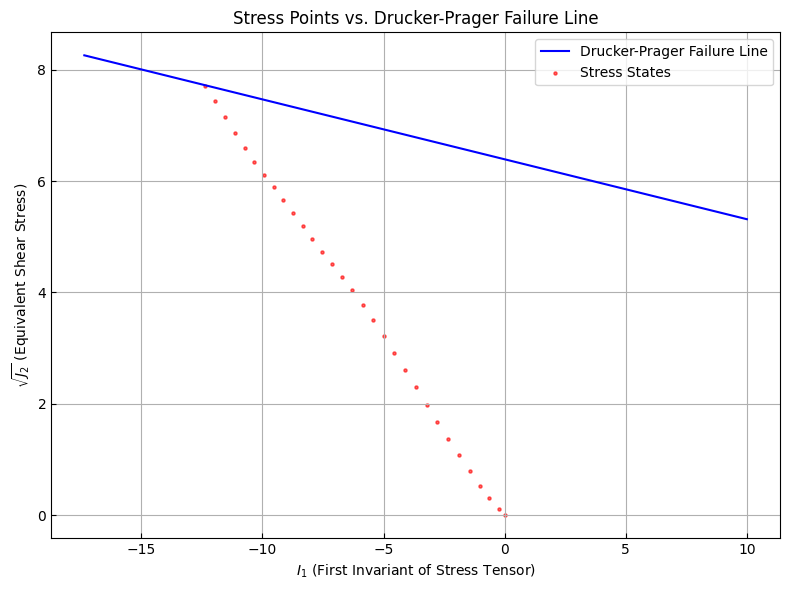

In [43]:
# drucker_prager_with_xarray.py

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=eletag).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=eletag).values
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=eletag).values

# Step 2: Compute I1 = σ11 + σ22 + σ33
I1_vals = sigma11 + sigma22 + sigma33  # First invariant of the stress tensor

# Step 3: Compute deviatoric stress s = σ - (1/3) I1
mean_stress = I1_vals / 3
s11 = sigma11 - mean_stress
s22 = sigma22 - mean_stress
s33 = sigma33 - mean_stress

# Step 4: Compute sqrt(J2) = sqrt(0.5 * (s11² + s22² + s33²))
J2_vals = 0.5 * (s11**2 + s22**2 + s33**2)
sqrt_J2_vals = np.sqrt(J2_vals)

# Step 5: Flatten for scatter plotting
I1_flat = I1_vals.flatten()
sqrt_J2_flat = sqrt_J2_vals.flatten()

# Step 6: Drucker-Prager failure line
rho = rho
sigma_Y = sigmay
I1_line = np.linspace(np.min(I1_flat)-5, np.max(I1_flat)+10, 500)
dp_line = - (1 / np.sqrt(2)) * rho * I1_line + (1 / np.sqrt(2)) * sigma_Y

# Step 7: Plot
plt.figure(figsize=(8, 6))
plt.plot(I1_line, dp_line, label='Drucker-Prager Failure Line', color='blue')
plt.scatter(I1_flat, sqrt_J2_flat, s=5, color='red', alpha=0.6, label='Stress States')

plt.xlabel(r'$I_1$ (First Invariant of Stress Tensor)')
plt.ylabel(r'$\sqrt{J_2}$ (Equivalent Shear Stress)')
plt.title('Stress Points vs. Drucker-Prager Failure Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
